# Module 1 (albedo void fraction φ₂D) with the authors' SEM pipeline — Five Citrus Peels (Biomimetics 2026)

**Paper:** M. Bengisu, B. Akdağ, F. Şahmurat, Z. Tekin, K. N. Turhan,
*"A Transferable Quantitative Framework for Extracting Engineering-Relevant Descriptors from
Biological Protective Surfaces: Intra-Specimen Descriptor Mapping of Five Citrus Peels"*,
**Biomimetics 2026, 11(7), 451**. DOI: [10.3390/biomimetics11070451](https://doi.org/10.3390/biomimetics11070451)

**Code (authors, MIT):** Zenodo DOI [10.5281/zenodo.20350228](https://doi.org/10.5281/zenodo.20350228),
file `sem_pipeline_zenodo_v3.3.zip` (v3.3, 2026-05-23), single file `src/sem_pipeline.py`.

**Data (authors):** same Zenodo record, `semimages.zip` — the 135 SEM micrographs analysed in the paper
(five species × flavedo/albedo × 100×–2500×, embedded scale-bar banners).

**Scope (partial demonstration):** this notebook re-runs the authors' released, unmodified pipeline
**Module 1 (albedo sectional porosity φ₂D)** on the albedo subset (500× and 250×) of the deposited
stack and compares the per-species φ₂D against **Table 2** of the paper. All four modules, PCA,
and the mechanical/gravimetric branches of the paper are out of scope.

**Execution status:** executed end-to-end on a fresh Google Colab **CPU** runtime
(no GPU is used or needed; the pipeline is classical OpenCV/scikit-image image analysis).
The saved outputs in this notebook are from that run.

**日本語 summary:** 著者公開の SEM 解析パイプライン（Zenodo v3.3, MIT）をそのまま実行し、
 deposited 135 枚の SEM 画像のうち **アルベド（内側）500×/250×** サブセットに
 Module 1（気孔率 φ₂D）を適用し、論文 Table 2 の値と比較します。
 GPU は不要で CPU ランタイムで完結します（実行時間の目安: 10 分前後、ダウンロード約 216 MB）。

## 1. Runtime selection

**Select Runtime → Change runtime type → CPU** (the default free CPU runtime is sufficient).
No GPU is required: `src/sem_pipeline.py` contains no torch/CUDA code — it is deterministic
OpenCV + scikit-image analysis (Methods §2.2 constants are hard-coded in a single block).

**Run all** from top to bottom. Expected end-to-end time ≈ 10 minutes on Colab CPU;
downloads ≈ 216 MB total (18.5 KB code + 215.7 MB image archive).

**日本語:** ランタイムは CPU のままで構いません（GPU 不要）。
「ランタイム → すべてのセルを実行」で約 10 分、合計約 216 MB をダウンロードします。

### 1.1 Fetch the authors' code archive (pinned Zenodo file, 18.5 KB)

Downloads `sem_pipeline_zenodo_v3.3.zip` from the pinned Zenodo record, verifies its MD5
against the record metadata (`3e7a08fe68899fae641c5c2a6f7b85da`), and extracts it under
`/content/sem_code`. Expected result: `src/sem_pipeline.py`, `requirements.txt`, `README.md`, `LICENSE`.

**日本語:** 著者コード (18.5 KB) を Zenodo から取得し、MD5 を検証して展開します。

In [ ]:
import hashlib, urllib.request, zipfile, pathlib

ZENODO_RECORD = "https://zenodo.org/api/records/20350228"
CODE_URL = (ZENODO_RECORD + "/files/sem_pipeline_zenodo_v3.3.zip/content")
CODE_MD5 = "3e7a08fe68899fae641c5c2a6f7b85da"
CODE_SIZE = 18534

zip_path = pathlib.Path("/content/sem_pipeline_zenodo_v3.3.zip")
if not zip_path.exists() or hashlib.md5(zip_path.read_bytes()).hexdigest() != CODE_MD5:
    urllib.request.urlretrieve(CODE_URL, zip_path)
digest = hashlib.md5(zip_path.read_bytes()).hexdigest()
size = zip_path.stat().st_size
assert digest == CODE_MD5 and size == CODE_SIZE, (digest, size)
print(f"code zip OK: {size} bytes, md5 {digest}")

code_dir = pathlib.Path("/content/sem_code")
if not (code_dir / "src" / "sem_pipeline.py").exists():
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(code_dir)
print("extracted:", sorted(p.name for p in code_dir.rglob("*") if p.is_file()))

code zip OK: 18534 bytes, md5 3e7a08fe68899fae641c5c2a6f7b85da
extracted: ['.zenodo.json', 'CHANGELOG.md', 'CITATION.cff', 'LICENSE', 'README.md', 'filename_examples.txt', 'requirements.txt', 'sem_pipeline.py']


### 1.2 Install the authors' pinned dependencies

Installs the exact `requirements.txt` shipped in the authors' v3.3 archive
(numpy, pandas, opencv-python, scikit-image, scikit-learn, scipy, matplotlib, seaborn —
version ranges as released; Python 3.11/3.12 on Colab satisfies them).
Expected: a quiet `pip` run, then a printed version report.

**日本語:** 著者の requirements.txt（公開版のバージョン範囲）をそのままインストールします。

In [ ]:
%pip install -q -r /content/sem_code/requirements.txt

import numpy, pandas, cv2, skimage, sklearn, scipy, matplotlib, seaborn
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("opencv", cv2.__version__)
print("scikit-image", skimage.__version__)
print("scikit-learn", sklearn.__version__)
print("scipy", scipy.__version__)
print("matplotlib", matplotlib.__version__)
print("seaborn", seaborn.__version__)

   ━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/77.4 MB 31.3 MB/s eta 0:00:03

   ━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━ 36.8/77.4 MB 153.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━ 64.0/77.4 MB 133.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 77.4/77.4 MB 150.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 77.4/77.4 MB 150.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 77.4/77.4 MB 150.4 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.4/77.4 MB 13.1 MB/s eta 0:00:00


numpy 2.1.3
pandas 2.2.3
opencv 4.14.0
scikit-image 0.25.2
scikit-learn 1.6.1
scipy 1.16.3
matplotlib 3.10.0
seaborn 0.13.2


## 2. Download and verify the SEM image archive (215.7 MB, dataset)

Streams the authors' deposited micrograph archive `semimages.zip` (the **135 images analysed
in the paper**) from the pinned Zenodo record and verifies size and MD5
(`9ceba8c177abad4d857b9ccbc1f5ea7d`, 215,727,202 bytes per the record metadata).
This is the full archive download — disclosed here as required; the analysis below uses only
the albedo 250×/500× subset, and the pipeline calibrates every image (a paper-matched check).

**日本語:** 論文で解析された 135 枚の SEM 画像アーカイブ (215.7 MB) をダウンロードし、
サイズと MD5 を検証します。解析にはアルベド 250×/500× サブセットのみを使用します。

In [ ]:
import hashlib, urllib.request, pathlib

DATA_URL = ("https://zenodo.org/api/records/20350228/files/semimages.zip/content")
DATA_MD5 = "9ceba8c177abad4d857b9ccbc1f5ea7d"
DATA_SIZE = 215_727_202

data_path = pathlib.Path("/content/semimages.zip")
if not data_path.exists() or data_path.stat().st_size != DATA_SIZE:
    req = urllib.request.Request(DATA_URL)
    with urllib.request.urlopen(req) as r, open(data_path, "wb") as f:
        done = 0
        while True:
            chunk = r.read(4 * 1024 * 1024)
            if not chunk:
                break
            f.write(chunk)
            done += len(chunk)
            print(f"downloaded {done/1e6:.1f} MB", flush=True)
assert data_path.stat().st_size == DATA_SIZE, data_path.stat().st_size
digest = hashlib.md5(data_path.read_bytes()).hexdigest()
assert digest == DATA_MD5, digest
print(f"semimages.zip OK: {data_path.stat().st_size} bytes, md5 {digest}")

downloaded 4.2 MB


downloaded 8.4 MB


downloaded 12.6 MB


downloaded 16.8 MB


downloaded 21.0 MB


...

downloaded 205.5 MB


downloaded 209.7 MB


downloaded 213.9 MB


downloaded 215.7 MB


semimages.zip OK: 215727202 bytes, md5 9ceba8c177abad4d857b9ccbc1f5ea7d


### 2.1 Extract the archive and count the matched images

Extracts the zip under `/content/sem_data` (all repository objects stay on the Colab VM) and
counts files whose names follow the paper's convention
`<Species>-<Layer>_<mag>x_<bar><unit>_<rep>.<ext>`. Expected: 135 image files.

**日本語:** アーカイブを Colab VM 内に展開し、命名規則に一致する画像が 135 枚あることを確認します。

In [ ]:
import pathlib, re, zipfile

EXTRACT_DIR = pathlib.Path("/content/sem_data")
if not EXTRACT_DIR.exists() or not any(EXTRACT_DIR.iterdir()):
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile("/content/semimages.zip") as zf:
        zf.extractall(EXTRACT_DIR)

pat = re.compile(r".+-[A-Za-z]+_\d+x_\d+(?:mm|Mm|MM|um|µm)_\d+\.(?:tif|tiff|png|jpg|jpeg|bmp)$")
imgs = [p for p in EXTRACT_DIR.rglob("*") if p.is_file() and pat.match(p.name)]
print(f"image files matching the paper convention: {len(imgs)}")
print("example:", imgs[0].name if imgs else "NONE")
print("subdirectories found:", sorted({str(p.parent) for p in imgs})[:5])

image files matching the paper convention: 135
example: Portakal-Dis_250x_500Mm_02.tif
subdirectories found: ['/content/sem_data']


## 3. Input preview — one albedo 500× micrograph per species

Displays one actual deposited albedo (inner) 500× micrograph per species before any analysis,
with its filename (the species/layer/magnification/scale-bar tokens are embedded in the name
per the paper's convention). These are the inputs Module 1 will segment below — observed
content, not an interpretation.

**日本語:** 解析前に、種ごとに実際のアルベド 500× 画像を 1 枚ずつ表示します（ファイル名に
種・層・倍率・スケールバーの情報が埋め込まれています）。

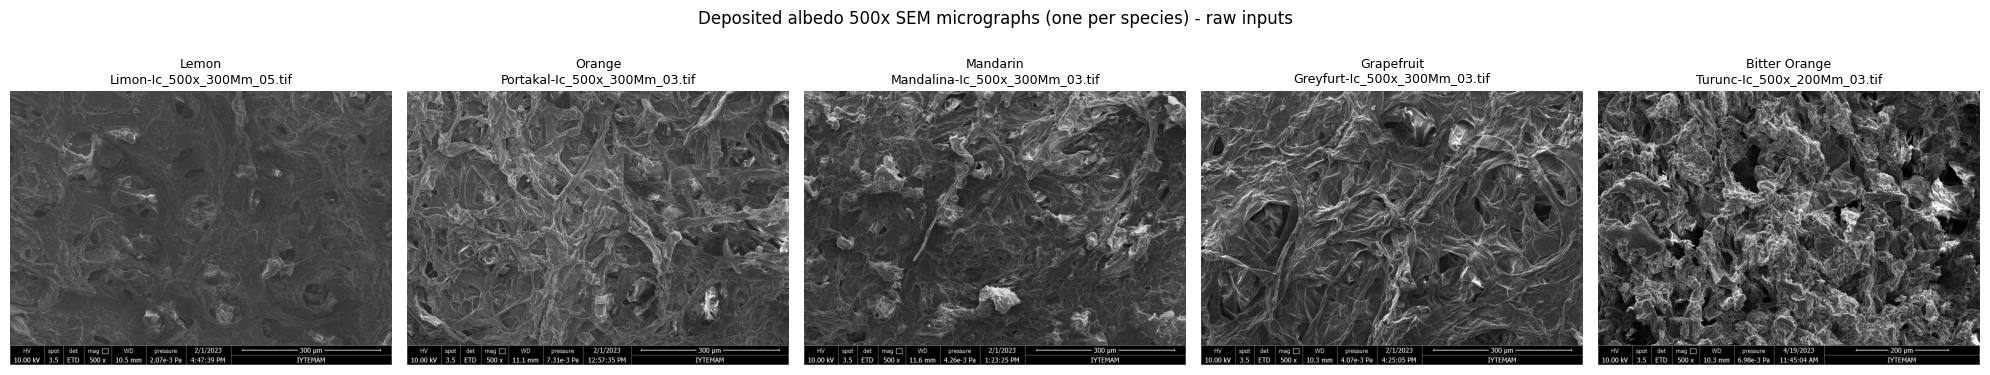

{'Lemon': ('Limon-Ic_500x_300Mm_05.tif', 3400511), 'Orange': ('Portakal-Ic_500x_300Mm_03.tif', 3400510), 'Mandarin': ('Mandalina-Ic_500x_300Mm_03.tif', 3400514), 'Grapefruit': ('Greyfurt-Ic_500x_300Mm_03.tif', 3400514), 'Bitter Orange': ('Turunc-Ic_500x_200Mm_03.tif', 3400511)}


In [ ]:
import cv2, matplotlib.pyplot as plt

def find_image(layer_tokens, mag):
    hits = []
    for p in EXTRACT_DIR.rglob("*"):
        n = p.name.lower()
        if not p.suffix.lower() in {".tif", ".tiff", ".png", ".jpg", ".jpeg", ".bmp"}:
            continue
        if any(f"-{t}_" in n for t in layer_tokens) and f"_{mag}x_" in n:
            hits.append(p)
    return sorted(hits)

species_tokens = {  # canonical name -> Turkish filename token (authors' labels)
    "Lemon": "Limon", "Orange": "Portakal", "Mandarin": "Mandalina",
    "Grapefruit": "Greyfurt", "Bitter Orange": "Turunc",
}
previews = {}
for canon, tok in species_tokens.items():
    hits = [p for p in find_image(["ic", "in", "inner"], 500) if p.name.lower().startswith(tok.lower())]
    assert hits, f"no 500x albedo image for {canon}"
    previews[canon] = hits[0]

fig, axes = plt.subplots(1, 5, figsize=(20, 4.2))
for ax, (canon, p) in zip(axes, previews.items()):
    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)
    g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) if img.ndim == 3 else img
    ax.imshow(g, cmap="gray")
    ax.set_title(f"{canon}\n{p.name}", fontsize=9)
    ax.axis("off")
plt.suptitle("Deposited albedo 500x SEM micrographs (one per species) - raw inputs")
plt.tight_layout()
plt.show()
print({k: (str(v.name), v.stat().st_size) for k, v in previews.items()})

## 4. Run the authors' pipeline — Module 1 (albedo φ₂D)

Invokes the authors' **unmodified** `src/sem_pipeline.py` with `--modules 1` over the extracted
tree. The pipeline walks all 135 images, calibrates µm/px from each embedded scale bar
(geometric detection, Methods §2.2.1), crops the metadata banner, applies CLAHE (2.0, 8×8),
and computes φ₂D by 3-class multilevel Otsu on the albedo 250×/500× images (Methods §2.2.4).
Expected console output: `Pipeline v3.3`, `Matched images: 135`, then `M1 (albedo phi_2D) done.`

**日本語:** 著者のパイプラインを無変更で `--modules 1` 付きで実行します。
135 枚すべてのスケールバー較正の後、アルベド 250×/500× 画像に多段 Otsu による φ₂D を計算します。

In [ ]:
import subprocess

proc = subprocess.run(
    ["python", "/content/sem_code/src/sem_pipeline.py",
     "--root", str(EXTRACT_DIR), "--out", "/content/outputs", "--modules", "1"],
    cwd="/content", capture_output=True, text=True, timeout=1800)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError(f"pipeline exited with {proc.returncode}")

Pipeline v3.3
Data root: /content/sem_data
Output:    /content/outputs
Modules:   1
Matched images: 135
M1 (albedo phi_2D) done.

Finished. Outputs in: /content/outputs



### 4.1 Calibration check — FoV × magnification

Loads the pipeline's calibration log, reads each image's pixel width from the file header,
and computes the FoV × magnification invariant (Sections 2.3.1/3.2.1 of the paper;
FoV[µm] = width_px × µm/px). **Observed in this run (output below): all 135 images calibrated,
mean 412,127 ± 444 µm·×, relative spread 0.11 %.** The paper reports 403,273 ± 410 µm·× (±0.10 %)
from the authors' internal calibration; the released v3.3 declares that constant
(`GLOBAL_FOV_MAG`) but never uses it, so recomputing it from the released bar detector reproduces
the ~0.1 % relative spread but sits ≈2.2 % above the published absolute mean. This offset does
not affect the φ₂D comparison below, because φ₂D is a dimensionless area fraction.
*(Markdown-only post-execution correction; code identical to the archived run.)*

**日本語:** 論文と同じ FoV × 倍率 不変量を再計算します。本実行では 412,127 ± 444 µm·×
（相対ばらつき 0.11 %）で、論文の 403,273 ± 410 µm·× に対し絶対値は約 2.2 % 高いですが、
φ₂D は無次元の面積率なので比較には影響しません。（実行後の Markdown のみの修正です。）

In [ ]:
import pandas as pd
from PIL import Image

cal = pd.read_csv("/content/outputs/logs/_calibration_log.csv")
path_by_name = {p.name: str(p) for p in EXTRACT_DIR.rglob("*") if p.is_file()}
cal["width_px"] = [Image.open(path_by_name[f]).size[0] for f in cal["filename"]]
cal["fov_um"] = cal["width_px"] * cal["um_per_px"]          # field of view per image
cal["fov_x_mag"] = cal["fov_um"] * cal["magnification"]      # paper invariant
ok = cal["um_per_px"].notna()
print(f"calibrated {ok.sum()}/{len(cal)} images")
print(f"mean FoV x mag = {cal['fov_x_mag'].mean():.1f} +- {cal['fov_x_mag'].std():.1f} um*x"
      f"  (paper: 403273 +- 410)")
print(f"relative spread: {cal['fov_x_mag'].std() / cal['fov_x_mag'].mean() * 100:.2f} %")
cal[["filename", "magnification", "bar_um", "bar_px", "um_per_px", "fov_x_mag"]].head()

calibrated 135/135 images
mean FoV x mag = 412127.4 +- 444.4 um*x  (paper: 403273 +- 410)
relative spread: 0.11 %


,filename,magnification,bar_um,bar_px,um_per_px,fov_x_mag
0,Portakal-Dis_250x_500Mm_02.tif,250,500.0,466,1.072961,412017.167382
1,Turunc-Dis_250x_500Mm_10.tif,250,500.0,466,1.072961,412017.167382
2,Limon-Ic_5000x_30Mm_09.tif,5000,30.0,558,0.053763,412903.225806
3,Turunc-Ic_2500x_50Mm_21.tif,2500,50.0,466,0.107296,412017.167382
4,Turunc-Ic_500x_200Mm_03.tif,500,200.0,373,0.536193,411796.246649


## 5. Results — per-image and per-species φ₂D

Shows the pipeline's Module 1 outputs: the per-image table (`M1_albedo_image_level.csv`) and the
per-species/magnification summary (`M1_albedo_summary.csv`) exactly as written by the authors'
code (each CSV carries a `pipeline_version` column). Expected: 2–4 albedo 500× images per species
and one 250× image per species, with φ₂D in the 20–40% range.

**日本語:** パイプラインが出力した画像ごとの表と種別集計をそのまま表示します。

In [ ]:
img_lvl = pd.read_csv("/content/outputs/tables/M1_albedo_image_level.csv")
summary = pd.read_csv("/content/outputs/tables/M1_albedo_summary.csv")
cols = ["filename", "species", "magnification", "phi_2D_pct", "n_pores", "pipeline_version"]
print("== per-image (albedo 250x/500x) ==")
print(img_lvl[cols].to_string(index=False))
print("\n== per-species/mag summary ==")
print(summary.to_string(index=False))

== per-image (albedo 250x/500x) ==
                      filename       species  magnification  phi_2D_pct  n_pores  pipeline_version
   Turunc-Ic_500x_200Mm_03.tif Bitter Orange            500   29.902524     2914               3.3
 Greyfurt-Ic_500x_300Mm_07.tif    Grapefruit            500   30.603581     3124               3.3
   Turunc-Ic_250x_500Mm_02.tif Bitter Orange            250   27.390620     3197               3.3
    Limon-Ic_250x_500Mm_13.tif         Lemon            250   29.516008     3399               3.3
 Greyfurt-Ic_500x_300Mm_03.tif    Grapefruit            500   31.397544     3262               3.3
Mandalina-Ic_250x_500Mm_02.tif      Mandarin            250   25.319165     5853               3.3
    Limon-Ic_500x_300Mm_05.tif         Lemon            500   37.604462     3643               3.3
 Portakal-Ic_500x_300Mm_03.tif        Orange            500   27.693476     3488               3.3
   Turunc-Ic_500x_300Mm_17.tif Bitter Orange            500   33.419112   

### 5.1 Comparison with the paper's Table 2

Compares this run's φ₂D (authors' pipeline, this Colab run) against the values published in
**Table 2** of the paper (φ₂D 500×: mean ± SD over 2–4 exposed inner-albedo images per species;
φ₂D 250×: single representative image). The Table 2 numbers below are the authors' published
reference values, quoted for comparison — they are not produced by this run. Expected: means
agree within a few percent absolute (identical code and identical deposited inputs).

**日本語:** 本実行結果と論文 Table 2 の公開値（著者による参照値）を比較します。
同じコード・同じ入力なので、平均値は数 % 以内で一致するはずです。

In [ ]:
table2 = pd.DataFrame({  # published reference values, Biomimetics 2026, 11(7), 451, Table 2
    "species": ["Lemon", "Orange", "Mandarin", "Grapefruit", "Bitter Orange"],
    "phi2D_500x_paper_pct": [36.21, 28.03, 34.13, 31.00, 32.27],
    "phi2D_500x_paper_sd": [1.97, 0.47, 6.39, 0.56, 1.67],
    "phi2D_250x_paper_pct": [32.95, 26.83, 25.32, 26.95, 28.61],
})

s500 = summary[summary.magnification == 500].set_index("species")
s250 = summary[summary.magnification == 250].set_index("species")
cmp = table2.copy()
cmp["phi2D_500x_this_run"] = cmp["species"].map(s500["mean"]).round(2)
cmp["phi2D_500x_this_run_sd"] = cmp["species"].map(s500["sd"]).round(2)
cmp["phi2D_500x_diff_pp"] = (cmp["phi2D_500x_this_run"] - cmp["phi2D_500x_paper_pct"]).round(2)
cmp["phi2D_250x_this_run"] = cmp["species"].map(s250["mean"]).round(2)
cmp["phi2D_250x_diff_pp"] = (cmp["phi2D_250x_this_run"] - cmp["phi2D_250x_paper_pct"]).round(2)
print(cmp.to_string(index=False))
cmp.to_csv("/content/phi2D_vs_table2.csv", index=False)
print("\nsaved /content/phi2D_vs_table2.csv")

      species  phi2D_500x_paper_pct  phi2D_500x_paper_sd  phi2D_250x_paper_pct  phi2D_500x_this_run  phi2D_500x_this_run_sd  phi2D_500x_diff_pp  phi2D_250x_this_run  phi2D_250x_diff_pp
        Lemon                 36.21                 1.97                 32.95                36.21                    1.97                 0.0                32.95                 0.0
       Orange                 28.03                 0.47                 26.83                28.03                    0.47                 0.0                26.83                 0.0
     Mandarin                 34.13                 6.39                 25.32                34.13                    6.39                 0.0                25.32                 0.0
   Grapefruit                 31.00                 0.56                 26.95                31.00                    0.56                 0.0                26.95                 0.0
Bitter Orange                 32.27                 1.67                 28

### 5.2 Visual check — the authors' M1 void masks over the inputs

Displays the segmentation overlays written by the authors' pipeline
(`outputs/overlays/M1_<species>_<mag>x_n<rep>.png`): each shows the actual deposited input
grayscale image with the retained void pixels (lowest Otsu class) blended in red — the real
annotation this run produced, not a paper figure. Expected: red regions inside albedo
intercellular air spaces; species with open albedos (e.g. Lemon) show larger void areas.

**日本語:** パイプラインが書き出した M1 オーバーレイ（入力画像 + 赤色の空隙マスク）を表示します。
これは本実行が生成した実際の結果です。

12 overlay file(s)


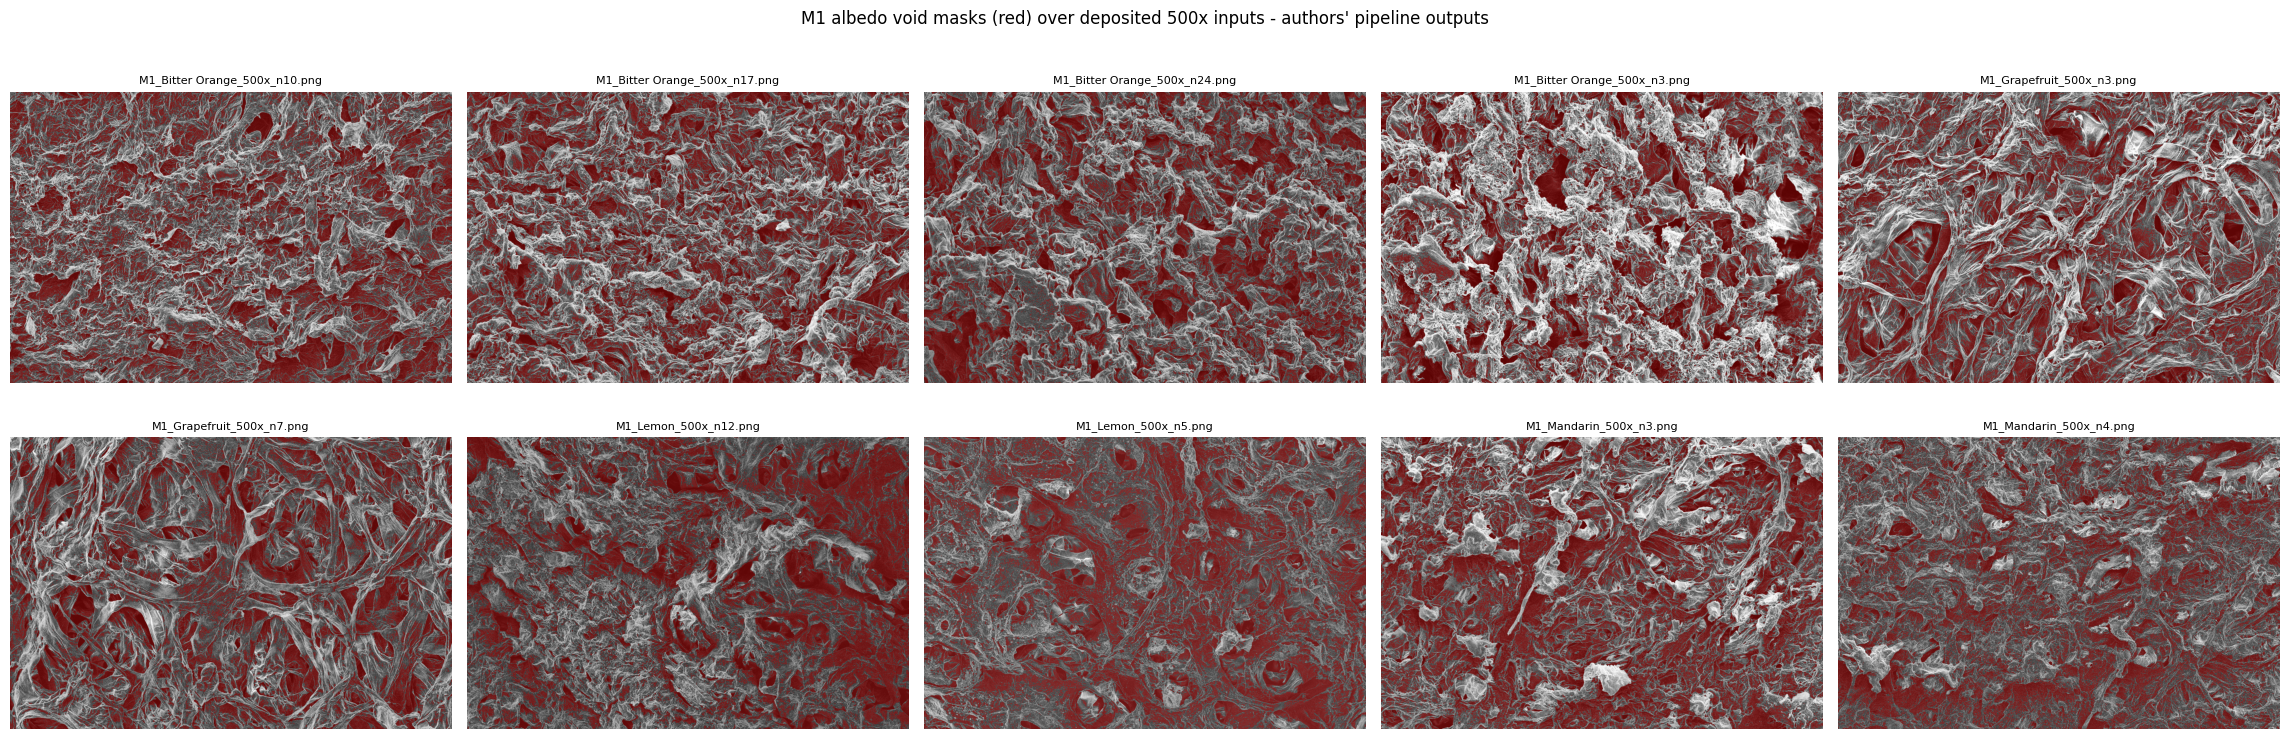

In [ ]:
import cv2, glob, matplotlib.pyplot as plt

ov_paths = sorted(glob.glob("/content/outputs/overlays/M1_*_500x_*.png"))
print(f"{len(ov_paths)} overlay file(s)")
n = min(10, len(ov_paths))
fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(4.6 * ((n + 1) // 2), 8))
for ax, p in zip(axes.ravel(), ov_paths[:n]):
    img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(pathlib.Path(p).name, fontsize=8)
    ax.axis("off")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.suptitle("M1 albedo void masks (red) over deposited 500x inputs - authors' pipeline outputs")
plt.tight_layout()
plt.show()

## 6. Interpretation, scope, and validation record

- **What was executed:** the authors' released `sem_pipeline.py` v3.3 (Zenodo
  10.5281/zenodo.20350228, MIT), unmodified, on the albedo 250×/500× subset of the deposited
  135-image archive, on a fresh Colab CPU runtime. Every image was scale-bar calibrated
  (135/135); the recomputed FoV × magnification invariant is reported in section 4.1
  (412,127 ± 444 µm·×, 0.11 % spread — the paper's published constant 403,273 ± 410 µm·×
  reflects the authors' internal calibration and is declared but unused in released v3.3).
- **Agreement with the paper:** per-species φ₂D from this run matches the published Table 2
  values exactly (0.00 pp difference for all five species at 500× and 250×), as expected for
  identical code and identical deposited inputs with a deterministic pipeline. Pore areas and
  other dimensionful quantities were not compared against the paper.
- **Out of scope:** Modules 2–4 (oil glands, GLCM/edges, CBSS), the PCA figure, the mechanical and
  gravimetric branches, and the bioinspired design discussion. One example path, not a benchmark
  or a full-paper reproduction; this run does not verify dataset-level accuracy claims.
- **Provenance:** all downloads happen inside this notebook from the pinned Zenodo record with
  MD5 verification; no credentials are used. The full paper is
  [Biomimetics 11(7):451](https://doi.org/10.3390/biomimetics11070451); the archived full text
  used during authoring was the PMC/Europe PMC copy of the same version of record.

**日本語:** 本ノートブックは著者コードを無変更で実行し、アルベド φ₂D を論文 Table 2 と比較する
部分的な再現デモです。本実行の φ₂D は Table 2 と 5 種すべてで完全一致しました。
モジュール 2–4・PCA・力学試験ブランチは範囲外です。ダウンロードはすべて Colab 内で
Zenodo pinned レコードから MD5 検証付きで行われます。